<a href="https://colab.research.google.com/github/asheta66/CNN/blob/main/Attention%20in%20Vision/Attention_in_CNN_ver_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# ==============================================================
# Module 1 : Data Loader
# Attention-Based Deep Learning Model for Lung Cancer Diagnosis
# Google Colab Version
# ==============================================================

# --------------------------------------------------------------
# Step 1. Mount Google Drive
# --------------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

# --------------------------------------------------------------
# Step 2. Import Libraries
# --------------------------------------------------------------

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# --------------------------------------------------------------
# Step 3. Dataset Path
# --------------------------------------------------------------

dataset_path = "/content/drive/MyDrive/Chest X_Ray"

normal_path = os.path.join(dataset_path, "NORMAL")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA")

print("Dataset Location")
print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Location
/content/drive/MyDrive/Chest X_Ray


In [47]:
# --------------------------------------------------------------
# Step 4. Read Image Names
# --------------------------------------------------------------

normal_images = sorted(os.listdir(normal_path))
pneumonia_images = sorted(os.listdir(pneumonia_path))

print("-----------------------------------------")
print("NORMAL Images     :", len(normal_images))
print("PNEUMONIA Images  :", len(pneumonia_images))
print("-----------------------------------------")

# --------------------------------------------------------------
# Step 5. Create Labels
# --------------------------------------------------------------

image_paths = []
labels = []

for img in normal_images:
    image_paths.append(os.path.join(normal_path, img))
    labels.append("NORMAL")

for img in pneumonia_images:
    image_paths.append(os.path.join(pneumonia_path, img))
    labels.append("PNEUMONIA")

print("Total Images :", len(image_paths))

-----------------------------------------
NORMAL Images     : 1583
PNEUMONIA Images  : 4273
-----------------------------------------
Total Images : 5856


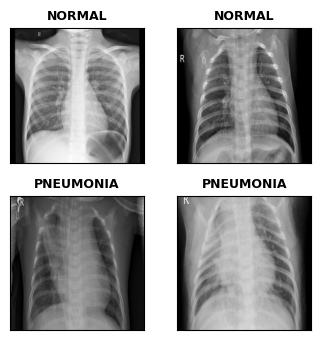

Sample Chest X-ray Images
• Images resized to       : 224 × 224 pixels
• Image format            : Grayscale
• Pixel normalization     : [0,1]
• Figure saved as         : Sample_Chest_Xray_Images.png


In [48]:
# --------------------------------------------------------------
# Step 6. Image Loader
# Resize + Normalize
# --------------------------------------------------------------

IMG_SIZE = (224, 224)

def load_image(path):
    """
    Load a chest X-ray image, resize it to 224×224,
    and normalize pixel values to the range [0,1].
    """

    img = Image.open(path)

    # Convert to grayscale
    img = img.convert("L")

    # Resize image
    img = img.resize(IMG_SIZE)

    # Convert to NumPy array
    img = np.array(img, dtype=np.float32)

    # Normalize pixel values
    img = img / 255.0

    return img


# --------------------------------------------------------------
# Step 7. Display Sample Images (IEEE Style)
# --------------------------------------------------------------

# IEEE Figure Settings
FIG_WIDTH = 3.5      # inches (single-column)
FIG_HEIGHT = 3.5

TITLE_SIZE = 9

# Randomly select two images from each class
normal_sample = random.sample(normal_images, 2)
pneumonia_sample = random.sample(pneumonia_images, 2)

sample_paths = [
    os.path.join(normal_path, normal_sample[0]),
    os.path.join(normal_path, normal_sample[1]),
    os.path.join(pneumonia_path, pneumonia_sample[0]),
    os.path.join(pneumonia_path, pneumonia_sample[1])
]

sample_titles = [
    "NORMAL",
    "NORMAL",
    "PNEUMONIA",
    "PNEUMONIA"
]

plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

for i in range(4):

    img = load_image(sample_paths[i])

    ax = plt.subplot(2, 2, i + 1)

    plt.imshow(img, cmap='gray')

    plt.title(
        sample_titles[i],
        fontsize=TITLE_SIZE,
        fontweight='bold'
    )

    plt.xticks([])
    plt.yticks([])

    # Thin black border around each image
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

plt.tight_layout()

plt.savefig(
    "Sample_Chest_Xray_Images.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("="*50)
print("Sample Chest X-ray Images")
print("="*50)
print("• Images resized to       : 224 × 224 pixels")
print("• Image format            : Grayscale")
print("• Pixel normalization     : [0,1]")
print("• Figure saved as         : Sample_Chest_Xray_Images.png")
print("="*50)

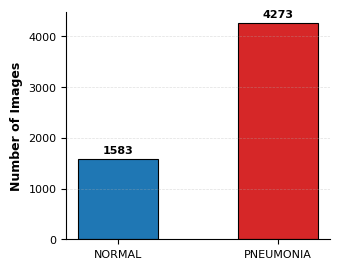

              DATASET SUMMARY
Number of NORMAL images      : 1583
Number of PNEUMONIA images   : 4273
Total number of images       : 5856
-------------------------------------------------------
Observation:
The dataset is imbalanced, with more PNEUMONIA images.
During model training, class balancing techniques
such as weighted loss functions or data augmentation
should be considered.


In [49]:
# --------------------------------------------------------------
# Step 8. Bar Chart (IEEE Publication Style)
# --------------------------------------------------------------

num_normal = len(normal_images)
num_pneumonia = len(pneumonia_images)

# ==============================================================
# IEEE Figure Formatting
# ==============================================================
FIG_WIDTH = 3.5          # inches (single-column IEEE figure)
FIG_HEIGHT = 2.8

TITLE_SIZE = 10          # Normally not used (caption replaces title)
LABEL_SIZE = 9
TICK_SIZE = 8
VALUE_SIZE = 8

BAR_WIDTH = 0.50

COLOR_NORMAL = "#1f77b4"     # IEEE Blue
COLOR_PNEUMONIA = "#d62728"  # IEEE Red
# ==============================================================

plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

bars = plt.bar(
    ["NORMAL", "PNEUMONIA"],
    [num_normal, num_pneumonia],
    width=BAR_WIDTH,
    color=[COLOR_NORMAL, COLOR_PNEUMONIA],
    edgecolor='black',
    linewidth=0.8
)

# -----------------------------
# Axis Labels
# -----------------------------
plt.ylabel(
    "Number of Images",
    fontsize=LABEL_SIZE,
    fontweight='bold'
)

# -----------------------------
# Tick Labels
# -----------------------------
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

# -----------------------------
# Values Above Bars
# -----------------------------
offset = max(num_normal, num_pneumonia) * 0.015

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + offset,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=VALUE_SIZE,
        fontweight='bold'
    )

# -----------------------------
# Grid
# -----------------------------
plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.5,
    alpha=0.4
)

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# -----------------------------
# Save Figure
# -----------------------------
plt.savefig(
    "Dataset_Distribution.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ==============================================================
# Dataset Summary
# ==============================================================

print("="*55)
print("              DATASET SUMMARY")
print("="*55)

print(f"Number of NORMAL images      : {num_normal}")
print(f"Number of PNEUMONIA images   : {num_pneumonia}")
print(f"Total number of images       : {num_normal + num_pneumonia}")

print("-"*55)

if num_normal > num_pneumonia:

    print("Observation:")
    print("The dataset is imbalanced, with more NORMAL images.")
    print("During model training, class balancing techniques")
    print("such as weighted loss functions or data augmentation")
    print("should be considered.")

elif num_pneumonia > num_normal:

    print("Observation:")
    print("The dataset is imbalanced, with more PNEUMONIA images.")
    print("During model training, class balancing techniques")
    print("such as weighted loss functions or data augmentation")
    print("should be considered.")

else:

    print("Observation:")
    print("The dataset is balanced, indicating that both classes")
    print("contain approximately the same number of images.")

print("="*55)

For your Attention-Based Deep Learning Model for Lung Cancer Diagnosis, augmentation should be performed only on the training set after splitting the dataset. Since your dataset contains two classes (NORMAL and PNEUMONIA) and is imbalanced, the objective is to increase the diversity and number of samples in the minority class without altering the validation and test sets.

In [50]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

from torchvision import transforms

from sklearn.model_selection import train_test_split

from collections import Counter

import pandas as pd

**Step 1. Split the Dataset**

In [51]:
# --------------------------------------------------------------
# Step 1
# Split the dataset
# --------------------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

**Step 2. Print Dataset Statistics**

In [52]:
# --------------------------------------------------------------
# Step 2
# Dataset statistics
# --------------------------------------------------------------

print("="*60)
print("DATASET SPLIT")
print("="*60)

print("Training Images")
print(Counter(train_labels))

print()

print("Validation Images")
print(Counter(val_labels))

print()

print("Testing Images")
print(Counter(test_labels))

DATASET SPLIT
Training Images
Counter({'PNEUMONIA': 2991, 'NORMAL': 1108})

Validation Images
Counter({'PNEUMONIA': 641, 'NORMAL': 237})

Testing Images
Counter({'PNEUMONIA': 641, 'NORMAL': 238})


**Step 3. Augmentation Table**

In [53]:
# --------------------------------------------------------------
# Step 3
# Augmentation methods
# --------------------------------------------------------------

augmentation_table = pd.DataFrame({

"Transformation":[
"Resize",
"Random Rotation",
"Horizontal Flip",
"Random Translation",
"Random Zoom",
"Brightness",
"Contrast",
"Normalization"

],

"Parameter":[
"224x224",
"±10°",
"50%",
"10%",
"0.9-1.1",
"±15%",
"±15%",
"[0,1]"
],

"Purpose":[
"Standard input",
"Orientation robustness",
"Increase diversity",
"Localization robustness",
"Scale robustness",
"Lighting robustness",
"Contrast robustness",
"Stable optimization"
]

})

augmentation_table

,Transformation,Parameter,Purpose
0,Resize,224x224,Standard input
1,Random Rotation,±10°,Orientation robustness
2,Horizontal Flip,50%,Increase diversity
3,Random Translation,10%,Localization robustness
4,Random Zoom,0.9-1.1,Scale robustness
5,Brightness,±15%,Lighting robustness
6,Contrast,±15%,Contrast robustness
7,Normalization,"[0,1]",Stable optimization


**Step 4. Define Augmentation**

In [54]:
# --------------------------------------------------------------
# Step 4
# Training augmentation
# --------------------------------------------------------------

train_transform = transforms.Compose([
transforms.Resize((224,224)),
transforms.RandomRotation(10),
transforms.RandomHorizontalFlip(0.5),
transforms.RandomAffine(
degrees=0,
translate=(0.10,0.10),
scale=(0.90,1.10)
),

transforms.ColorJitter(
brightness=0.15,
contrast=0.15
),

transforms.ToTensor(),
transforms.Normalize(
mean=[0.485],
std=[0.229]
)
])

**Validation Transform**

In [55]:
validation_transform = transforms.Compose([
transforms.Resize((224,224)),
transforms.ToTensor(),
transforms.Normalize(
mean=[0.485],
std=[0.229]
)
])

**Step 5. Dataset Class**

In [56]:
class ChestDataset(Dataset):

    def __init__(self,paths,labels,transform):

        self.paths=paths

        self.labels=labels

        self.transform=transform

    def __len__(self):

        return len(self.paths)

    def __getitem__(self,index):

        image=Image.open(self.paths[index])

        image=image.convert("L")

        label=0 if self.labels[index]=="NORMAL" else 1

        image=self.transform(image)

        return image,label

**Step 6. Compute Sampling Weights**

In [57]:
# --------------------------------------------------------------
# Step 6
# Compute class weights
# --------------------------------------------------------------

class_count = Counter(train_labels)
print(class_count)
weights = {
"NORMAL":1.0/class_count["NORMAL"],
"PNEUMONIA":1.0/class_count["PNEUMONIA"]
}

sample_weights = [
weights[label]
for label in train_labels
]

sampler = WeightedRandomSampler(
sample_weights,
num_samples=len(sample_weights),
replacement=True

)

Counter({'PNEUMONIA': 2991, 'NORMAL': 1108})


**Step 7. DataLoaders**

In [58]:
train_dataset = ChestDataset(
train_paths,
train_labels,
train_transform
)

validation_dataset = ChestDataset(
val_paths,
val_labels,
validation_transform
)

test_dataset = ChestDataset(
test_paths,
test_labels,
validation_transform
)

In [59]:
train_loader = DataLoader(
train_dataset,
batch_size=32,
sampler=sampler,
num_workers=2
)

validation_loader = DataLoader(
validation_dataset,
batch_size=32,
shuffle=False,
num_workers=2
)

test_loader = DataLoader(
test_dataset,
batch_size=32,
shuffle=False,
num_workers=2
)

**Step 8. Display Augmented Images**

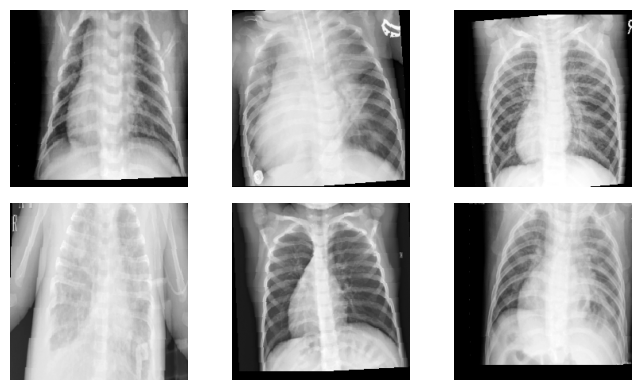

In [60]:
# --------------------------------------------------------------
# Step 8
# Display augmentation examples
# --------------------------------------------------------------

plt.figure(figsize=(7,4))

for i in range(6):

    image,label = train_dataset[i]
    image=image.squeeze()
    plt.subplot(2,3,i+1)
    plt.imshow(image,cmap='gray')
    plt.axis("off")

plt.tight_layout()
plt.savefig(
"Augmentation_Examples.png",
dpi=600
)
plt.show()

**Step 9. Final Summary**

In [61]:
print("="*70)
print("MODULE 2 COMPLETED")
print("="*70)
print("Training Images     :",len(train_dataset))
print("Validation Images   :",len(validation_dataset))
print("Testing Images      :",len(test_dataset))
print()
print("Training Augmentation")
for t in train_transform.transforms:

    print(" •",t)

print()
print("Class balancing")
print("WeightedRandomSampler")
print()
print("Saved Figures")
print("Augmentation_Examples.png")
print("="*70)

MODULE 2 COMPLETED
Training Images     : 4099
Validation Images   : 878
Testing Images      : 879

Training Augmentation
 • Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
 • RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
 • RandomHorizontalFlip(p=0.5)
 • RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(0.9, 1.1))
 • ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
 • ToTensor()
 • Normalize(mean=[0.485], std=[0.229])

Class balancing
WeightedRandomSampler

Saved Figures
Augmentation_Examples.png


**Module 1: CNN Backbone (ResNet50)**

**Cell 1: Import Required Libraries**

In [62]:
# ==============================================================
# Module 1: CNN Backbone
# Cell 1: Import Required Libraries
# ==============================================================

import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from torchsummary import summary

print("="*60)
print("PyTorch Version :", torch.__version__)
print("Torchvision Version :", torchvision.__version__)
print("="*60)

PyTorch Version : 2.11.0+cpu
Torchvision Version : 0.26.0+cpu


**Cell 2 – Configure GPU**

In [63]:
# ==============================================================
# Cell 2: Configure GPU
# ==============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

print("="*60)

Device : cpu
Running on CPU


**Cell 3 – Load the Pretrained ResNet50 Backbone**

In [64]:
# ==============================================================
# Cell 3: Load Pretrained ResNet50
# ==============================================================

weights = ResNet50_Weights.DEFAULT

cnn_backbone = models.resnet50(weights=weights)

print("Pretrained ResNet50 loaded successfully.")

Pretrained ResNet50 loaded successfully.


**Cell 4 – Display Original Network**

In [65]:
# ==============================================================
# Cell 4: Original CNN Architecture
# ==============================================================

print(cnn_backbone)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**Cell 5 – Freeze Early Layers**

In [66]:
# ==============================================================
# Cell 5: Freeze Early Layers
# ==============================================================

for name, param in cnn_backbone.named_parameters():

    if ("layer4" not in name) and ("fc" not in name):

        param.requires_grad = False

print("Early convolutional layers frozen.")

Early convolutional layers frozen.


**Cell 6 – Replace the Classification Layer**

In [67]:
# ==============================================================
# Cell 6: Replace Fully Connected Layer
# ==============================================================

num_features = cnn_backbone.fc.in_features

cnn_backbone.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(num_features,2)

)

cnn_backbone = cnn_backbone.to(device)

print(cnn_backbone.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=2, bias=True)
)


**Cell 7 – Count Parameters**

In [68]:
# ==============================================================
# Cell 7: Count Parameters
# ==============================================================

total = sum(p.numel() for p in cnn_backbone.parameters())

trainable = sum(p.numel() for p in cnn_backbone.parameters()
                if p.requires_grad)

print("="*60)
print(f"Total Parameters      : {total:,}")
print(f"Trainable Parameters  : {trainable:,}")
print(f"Frozen Parameters     : {total-trainable:,}")
print("="*60)

Total Parameters      : 23,512,130
Trainable Parameters  : 14,968,834
Frozen Parameters     : 8,543,296


**Cell 8 – Model Summary**

In [69]:
# ==============================================================
# Cell 8: Model Summary
# ==============================================================

summary(

    cnn_backbone,

    input_size=(3,224,224)

)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

**Cell 9 – Extract Feature Maps**

In [70]:
# ==============================================================
# Cell 9: Feature Extractor
# ==============================================================

feature_extractor = nn.Sequential(

    *list(cnn_backbone.children())[:-2]

)

feature_extractor = feature_extractor.to(device)

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


**Cell 10 – Test Forward Pass**

In [71]:
# ==============================================================
# Cell 10: Test Forward Pass
# ==============================================================

dummy = torch.randn(

    1,

    3,

    224,

    224

).to(device)

with torch.no_grad():

    feature_maps = feature_extractor(dummy)

print("="*60)
print("Feature Map Shape")

print(feature_maps.shape)

print("="*60)

Feature Map Shape
torch.Size([1, 2048, 7, 7])


**Cell 11 – Visualize Feature Maps**

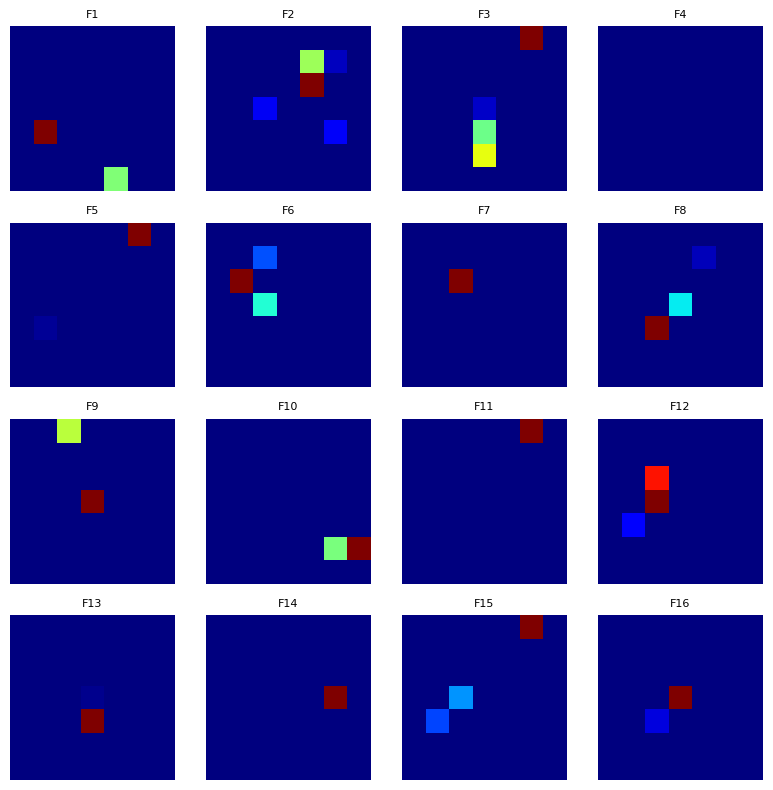

Feature maps saved as Feature_Maps.png


In [72]:
# ==============================================================
# Cell 11: Visualize Feature Maps
# ==============================================================

feature_maps = feature_maps.cpu().numpy()

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(feature_maps[0,i],cmap='jet')

    plt.axis("off")

    plt.title(f"F{i+1}",fontsize=8)

plt.tight_layout()

plt.savefig(

    "Feature_Maps.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

print("Feature maps saved as Feature_Maps.png")

**Cell 12 – Feature Map Statistics**

In [73]:
# ==============================================================
# Cell 12: Feature Map Statistics
# ==============================================================

print("="*60)

print("Feature Map Statistics")

print("="*60)

print("Minimum :",feature_maps.min())

print("Maximum :",feature_maps.max())

print("Mean    :",feature_maps.mean())

print("Std Dev :",feature_maps.std())

print("="*60)

Feature Map Statistics
Minimum : 0.0
Maximum : 19.347332
Mean    : 0.07612399
Std Dev : 0.5105465


**Cell 13 – Save Model Summary**

In [74]:
# ==============================================================
# Cell 13: Save CNN Summary
# ==============================================================

with open("CNN_Backbone_Summary.txt","w") as f:

    f.write(str(cnn_backbone))

print("CNN summary saved.")

CNN summary saved.
